In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\Multimodal Personality-Driven Career Intelligence System\data\personality_dataset\mbti_1.csv")

print(df.shape)

(8675, 2)


In [2]:
df.head()


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [3]:
import re

def clean_text(text):
    
    # Split posts separated by |||
    text = text.replace("|||", " ")

    # Remove links
    text = re.sub(r"http\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [4]:
df["clean_posts"] = df["posts"].apply(clean_text)


In [5]:
df[["posts", "clean_posts"]].head()


,posts,clean_posts
0,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,enfp and intj moments sportscenter not top ten...
1,'I'm finding the lack of me in these posts ver...,im finding the lack of me in these posts very ...
2,'Good one _____ https://www.youtube.com/wat...,good one of course to which i say i know thats...
3,"'Dear INTP, I enjoyed our conversation the o...",dear intp i enjoyed our conversation the other...
4,'You're fired.|||That's another silly misconce...,youre fired thats another silly misconception ...


In [6]:
df["type"].value_counts()

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64

In [7]:
top_types = [
    "INFP", "INFJ", "INTP", "INTJ",
    "ENTP", "ENFP", "ISTP", "ISFP"
]

In [8]:
df = df[df["type"].isin(top_types)]

In [9]:
df["type"].value_counts()


type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["label"] = le.fit_transform(df["type"])

In [11]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

{'ENFP': np.int64(0), 'ENTP': np.int64(1), 'INFJ': np.int64(2), 'INFP': np.int64(3), 'INTJ': np.int64(4), 'INTP': np.int64(5), 'ISFP': np.int64(6), 'ISTP': np.int64(7)}


In [12]:
df[["type", "label"]].head()

,type,label
0,INFJ,2
1,ENTP,1
2,INTP,5
3,INTJ,4
5,INTJ,4


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["clean_posts"],     # cleaned text
    df["label"],           # encoded labels
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [15]:
print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))

Train size: 6132
Validation size: 1533


In [16]:
import pandas as pd

print(pd.Series(train_labels).value_counts())

label
3    1465
2    1176
5    1043
4     873
1     548
0     540
7     270
6     217
Name: count, dtype: int64


In [17]:
from transformers import DistilBertTokenizer

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [19]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [20]:
val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [21]:
list(train_encodings.keys())

['input_ids', 'attention_mask']

In [22]:
print(train_encodings["input_ids"][0][:20])

[101, 10047, 2019, 4372, 22540, 1998, 1045, 2293, 4372, 2102, 22578, 7916, 7916, 2828, 2070, 2360, 4372, 22540, 2070, 2360]


In [23]:
import torch

In [ ]:
class MBTIDataset(torch.utils.data.Dataset):
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

NameError: name 'torch' is not defined

In [25]:
train_dataset = MBTIDataset(train_encodings, train_labels)
val_dataset = MBTIDataset(val_encodings, val_labels)

In [26]:
print(train_dataset[0])

{'input_ids': tensor([  101, 10047,  2019,  4372, 22540,  1998,  1045,  2293,  4372,  2102,
        22578,  7916,  7916,  2828,  2070,  2360,  4372, 22540,  2070,  2360,
         1999, 22540,  2017,  2360,  9686,  2546, 25787,  2140,  1045,  2113,
         2003,  1045, 14396,  2000,  2014,  2926,  1999,  1996,  2927,  2007,
         2014,  7570, 27982,  4606,  2006,  1037,  3167,  3602,  1045,  2113,
         2049,  2066,  2000,  2022,  2058, 21572, 26557,  3064,  8840,  2140,
         2061,  2008, 12991, 13874,  2115,  2063,  2007,  1997,  2607,  1045,
         2812,  1045,  2123,  2102,  7499,  2017,  1045,  2293,  2129,  2017,
         7697,  2619,  2091,  2005, 12991,  3723,  4691,  1998,  2059,  2175,
         2046,  2017,  2219, 23979, 12991, 13874,  1997,  4372, 22540,  2015,
         2074,  8025,  2106,  2017,  2131,  2023, 11654,  2012,  7928,  2500,
         2081,  2008,  2020,  3565,  4895, 10258, 20097,  2075,  1997,  4372,
        22540,  2015,  3426,  2017,  2020,  2428, 

In [27]:
from transformers import DistilBertForSequenceClassification

In [2]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=8
)

NameError: name 'DistilBertForSequenceClassification' is not defined

In [29]:
from transformers import TrainingArguments, Trainer

In [30]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",     
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [31]:
import transformers
print(transformers.__version__)

5.2.0


In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [33]:
trainer.train()

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
trainer.evaluate()

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.3355792760849,
 'eval_runtime': 103.9686,
 'eval_samples_per_second': 14.745,
 'eval_steps_per_second': 1.847,
 'epoch': 2.0}

In [ ]:
import torch

def predict_personality(text):

    # Convert text → tokens
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    # Model prediction
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted label index
    pred = torch.argmax(outputs.logits, dim=1).item()

    return pred

In [ ]:
sample_text = "I enjoy solving logical problems and working alone on difficult challenges."

pred_label = predict_personality(sample_text)

print("Predicted label:", pred_label)

Predicted label: 5


In [ ]:
reverse_mapping = {v:k for k,v in label_mapping.items()}
print("Predicted personality:", reverse_mapping[pred_label])

Predicted personality: INTP


In [ ]:
test_text = "I love helping people, working in teams, and motivating others."

pred = predict_personality(test_text)
print(reverse_mapping[pred])

INFP


In [ ]:
test_text = "Hello, my name is Khushi. I am someone who enjoys interacting with people and building comfortable, meaningful conversations. I am currently pursuing my studies in Computer Science, and through academic work and peer interactions, I have developed strong communication skills and a structured approach toward learning and problem-solving"

pred = predict_personality(test_text)
print(reverse_mapping[pred])    

INTP


In [ ]:
import pandas as pd

career_df = pd.read_csv("../data/career_dataset/career_data.csv")

career_df.head()

,career,description
0,Data Scientist,Works with data analysis machine learning stat...
1,Machine Learning Engineer,Builds deploys and optimizes machine learning ...
2,AI Engineer,Develops artificial intelligence solutions dee...
3,Software Engineer,Designs develops and maintains software system...
4,Backend Developer,Builds server side logic APIs databases and sc...


In [ ]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading wei

In [ ]:
career_embeddings = embed_model.encode(
    career_df["description"].tolist()
)

In [ ]:
user_embedding = embed_model.encode([test_text])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(user_embedding, career_embeddings)

In [ ]:
top_indices = similarities[0].argsort()[-3:][::-1]

for idx in top_indices:
    print(career_df.iloc[idx]["career"])

Community Manager
Teacher
AI Education Specialist


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=3)

career_3d = pca.fit_transform(career_embeddings)

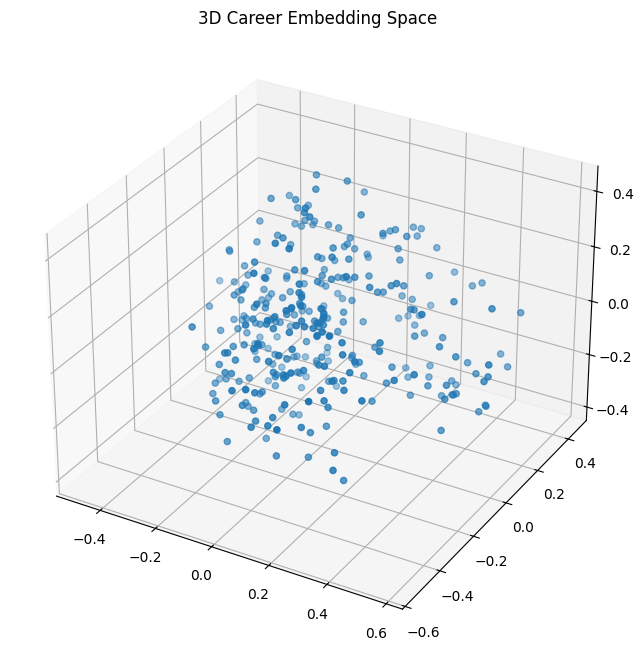

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    career_3d[:,0],
    career_3d[:,1],
    career_3d[:,2]
)

ax.set_title("3D Career Embedding Space")

plt.show()

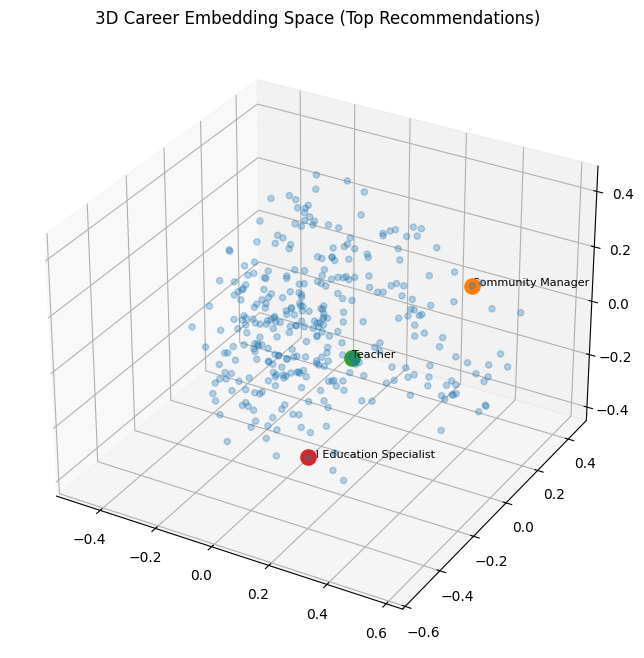

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# plot all careers
ax.scatter(
    career_3d[:,0],
    career_3d[:,1],
    career_3d[:,2],
    alpha=0.3
)

# highlight top recommendations
for idx in top_indices:
    ax.scatter(
        career_3d[idx,0],
        career_3d[idx,1],
        career_3d[idx,2],
        s=120
    )

    ax.text(
        career_3d[idx,0],
        career_3d[idx,1],
        career_3d[idx,2],
        career_df.iloc[idx]["career"],
        fontsize=8
    )

ax.set_title("3D Career Embedding Space (Top Recommendations)")
plt.show()

In [ ]:
for idx in top_indices:
    ax.text(
        career_3d[idx,0],
        career_3d[idx,1],
        career_3d[idx,2],
        career_df.iloc[idx]["career"],
        fontsize=8
    )

In [ ]:
user_text = """Hello, my name is Khushi. I enjoy structured learning, problem solving and meaningful conversations."""

# personality prediction
personality = predict_personality(user_text)
print("Predicted Personality:", personality)

# career recommendations
recommendations, top_indices = recommend_careers(user_text)

print("\nTop Career Recommendations:")
for career in recommendations:
    print("-", career)

# visualization
visualize_careers(top_indices)

Predicted Personality: 5


NameError: name 'recommend_careers' is not defined

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1030.71it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicted Personality: INTP

Top Career Recommendations:
- Teacher
- AI Education Specialist
- Community Manager
- Learning Experience Designer
- Digital Learning Scientist


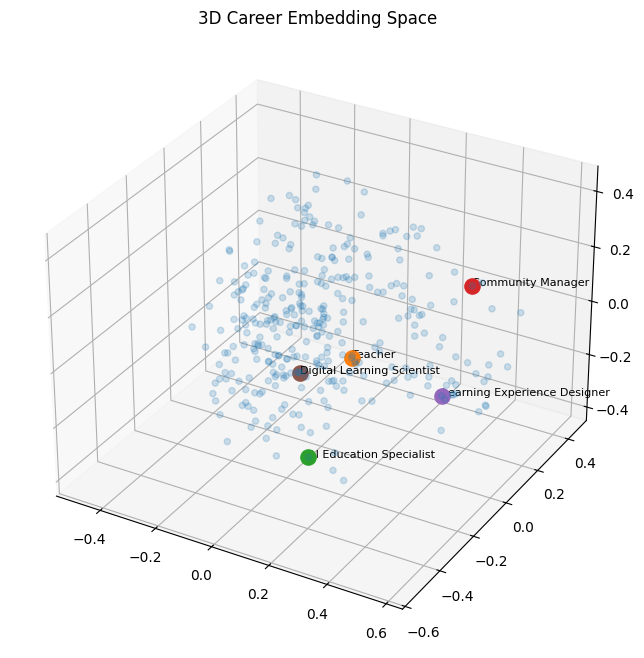

In [ ]:
import torch
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

career_df = pd.read_csv("../data/career_dataset/career_data.csv")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
career_embeddings = embed_model.encode(
    career_df["description"].tolist()
)

def predict_personality(text):

    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    return reverse_mapping[pred]

def recommend_careers(user_text, top_k=5):

    user_embedding = embed_model.encode([user_text])

    similarities = cosine_similarity(
        user_embedding,
        career_embeddings
    )

    top_indices = similarities[0].argsort()[-top_k:][::-1]

    recommendations = career_df.iloc[top_indices]["career"].tolist()

    return recommendations, top_indices


def visualize_careers(top_indices):

    pca = PCA(n_components=3)
    career_3d = pca.fit_transform(career_embeddings)

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    # all careers
    ax.scatter(
        career_3d[:,0],
        career_3d[:,1],
        career_3d[:,2],
        alpha=0.2
    )

    # highlight recommendations
    for idx in top_indices:
        ax.scatter(
            career_3d[idx,0],
            career_3d[idx,1],
            career_3d[idx,2],
            s=120
        )

        ax.text(
            career_3d[idx,0],
            career_3d[idx,1],
            career_3d[idx,2],
            career_df.iloc[idx]["career"],
            fontsize=8
        )

    ax.set_title("3D Career Embedding Space")
    plt.show()

    user_text = """Hello, my name is Khushi. I enjoy structured learning, problem solving and meaningful conversations."""

# personality prediction
personality = predict_personality(user_text)
print("Predicted Personality:", personality)

# career recommendations
recommendations, top_indices = recommend_careers(user_text)

print("\nTop Career Recommendations:")
for career in recommendations:
    print("-", career)

# visualization
visualize_careers(top_indices)